# Data Vis: Plotting Time Series Data
* Notebook 1: Smoothing and Trends

## Setup

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Data

In this notebook, we will use a private dataset about (solar) power generation and use of a single family house in Germany. The dataset contains the following columns:
- `timestamp`: The date and time of the measurement. The data is recorded every 1 hour.
- `total_consumption_kw`: The amount of power consumed per hour in kilowatts.
- `from_grid_kw`: The amount of power provided from the grid per hour in kilowatts.
- `from_pv_kw`: The amount of power generated by the solar panels per hour in kilowatts.
- `from_battery_kw`: The amount of power provided by the battery per hour in kilowatts.
- `to_grid_kw`: The amount of power provided to the grid per hour in kilowatts.
- `to_battery_kw`: The amount of power provided to the battery per hour in kilowatts.
- `battery_percent`: The average percentage of battery charge at the time of measurement.
- `battery_kwh`: The average amount of power in the battery at the time of measurement in kilowatt hours.
- various weather data, including temperature, humidity, precipitation, wind speed, and solar radiation (ghi, dni, dhi).

In [2]:
data = pd.read_csv("solar.csv")

In [3]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [4]:
data["year"] = data["timestamp"].dt.year
data["month"] = data["timestamp"].dt.month_name()
data["day"] = data["timestamp"].dt.day
data["hour"] = data["timestamp"].dt.hour
data["weekday"] = data["timestamp"].dt.day_name()
data["is_weekend"] = np.where(data["weekday"].isin(["Saturday", "Sunday"]), 1, 0)   

In [5]:
data.set_index("timestamp", inplace=True)

In [6]:
data.head()

,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,temperature_2m,...,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,year,month,day,hour,weekday,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-05-01 00:00:00+00:00,0.135,0.0,0.0,0.135,0.0,0.0,0.726,3.7026,0.0,14.962999,...,0.0,0.0,100.0,0.001960,2024,May,1,0,Wednesday,0
2024-05-01 01:00:00+00:00,0.132,0.0,0.0,0.132,0.0,0.0,0.684,3.4884,0.0,14.962999,...,0.0,16.0,90.0,0.010369,2024,May,1,1,Wednesday,0
2024-05-01 02:00:00+00:00,0.133,0.0,0.0,0.133,0.0,0.0,0.642,3.2742,0.0,15.263000,...,0.0,13.0,76.0,0.015774,2024,May,1,2,Wednesday,0
2024-05-01 03:00:00+00:00,0.093,0.0,0.0,0.093,0.0,0.0,0.610,3.1110,0.0,14.212999,...,0.0,21.0,0.0,0.006033,2024,May,1,3,Wednesday,0
2024-05-01 04:00:00+00:00,0.087,0.0,0.0,0.087,0.0,0.0,0.578,2.9478,0.0,12.763000,...,0.0,39.0,0.0,0.000000,2024,May,1,4,Wednesday,0


# Simple Moving Average

Let's first calculate a simple moving average (SMA) for the `from_pv_kw` column. The SMA is calculated by taking the average of the last `n` values in the series. We will use different `window` sizes and illustrate the effects.

In [7]:
data["from_pv_kw_rolling_mean_3"] = data["from_pv_kw"].rolling(window=3).mean()
data["from_pv_kw_rolling_mean_6"] = data["from_pv_kw"].rolling(window=6).mean()
data["from_pv_kw_rolling_mean_12"] = data["from_pv_kw"].rolling(window=12).mean()

In [8]:
data.head(20)

,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,temperature_2m,...,et0_fao_evapotranspiration,year,month,day,hour,weekday,is_weekend,from_pv_kw_rolling_mean_3,from_pv_kw_rolling_mean_6,from_pv_kw_rolling_mean_12
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-05-01 00:00:00+00:00,0.135,0.000,0.000,0.135,0.000,0.000,0.726,3.7026,0.000000e+00,14.962999,...,0.001960,2024,May,1,0,Wednesday,0,NaN,NaN,NaN
2024-05-01 01:00:00+00:00,0.132,0.000,0.000,0.132,0.000,0.000,0.684,3.4884,0.000000e+00,14.962999,...,0.010369,2024,May,1,1,Wednesday,0,NaN,NaN,NaN
2024-05-01 02:00:00+00:00,0.133,0.000,0.000,0.133,0.000,0.000,0.642,3.2742,0.000000e+00,15.263000,...,0.015774,2024,May,1,2,Wednesday,0,0.000000,NaN,NaN
2024-05-01 03:00:00+00:00,0.093,0.000,0.000,0.093,0.000,0.000,0.610,3.1110,0.000000e+00,14.212999,...,0.006033,2024,May,1,3,Wednesday,0,0.000000,NaN,NaN
2024-05-01 04:00:00+00:00,0.087,0.000,0.000,0.087,0.000,0.000,0.578,2.9478,0.000000e+00,12.763000,...,0.000000,2024,May,1,4,Wednesday,0,0.000000,NaN,NaN
2024-05-01 05:00:00+00:00,0.133,0.000,0.000,0.133,0.000,0.000,0.547,2.7897,0.000000e+00,13.563000,...,0.020594,2024,May,1,5,Wednesday,0,0.000000,0.000000,NaN
2024-05-01 06:00:00+00:00,0.160,0.000,0.000,0.160,0.000,0.000,0.505,2.5755,0.000000e+00,15.712999,...,0.079455,2024,May,1,6,Wednesday,0,0.000000,0.000000,NaN
2024-05-01 07:00:00+00:00,0.138,0.000,0.181,0.000,0.043,0.000,0.473,2.4123,0.000000e+00,18.063000,...,0.170618,2024,May,1,7,Wednesday,0,0.060333,0.030167,NaN
2024-05-01 08:00:00+00:00,0.177,0.000,1.386,0.000,0.001,1.208,0.578,2.9478,0.000000e+00,20.313000,...,0.279699,2024,May,1,8,Wednesday,0,0.522333,0.261167,NaN


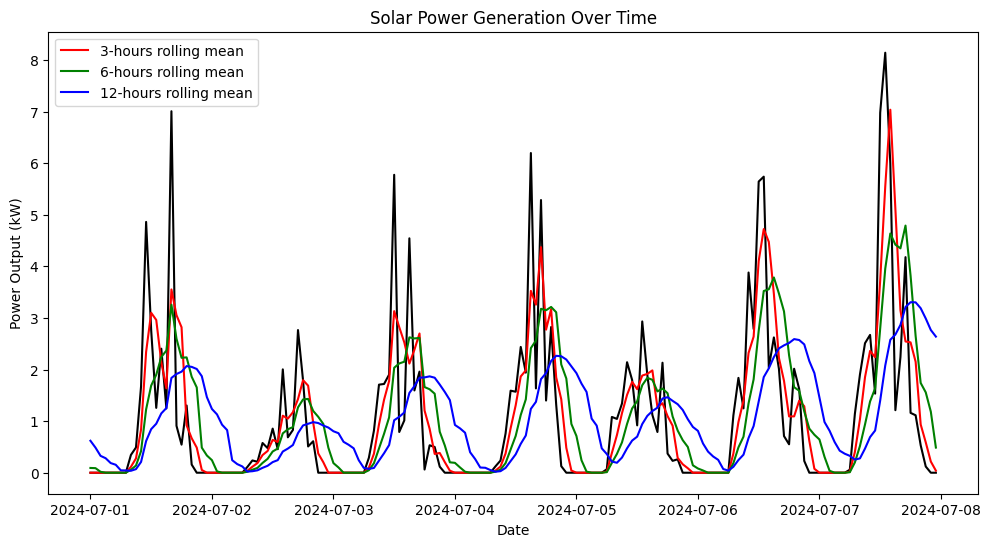

In [9]:
data_1week = data["2024-07-01":"2024-07-07"]

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_1week, x=data_1week.index, y="from_pv_kw", color="black")
sns.lineplot(data=data_1week, x=data_1week.index, y="from_pv_kw_rolling_mean_3", color="red", label="3-hours rolling mean")
sns.lineplot(data=data_1week, x=data_1week.index, y="from_pv_kw_rolling_mean_6", color="green", label="6-hours rolling mean")
sns.lineplot(data=data_1week, x=data_1week.index, y="from_pv_kw_rolling_mean_12", color="blue", label="12-hours rolling mean")
plt.title("Solar Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

# Trends with Functional Form

We can use `regplot` to add a linear or plolynomial regression line to line chart. Unfortunately, `regplot` does not support time indexes. So, we have to reset the index and use observation numbers on the x-axis.

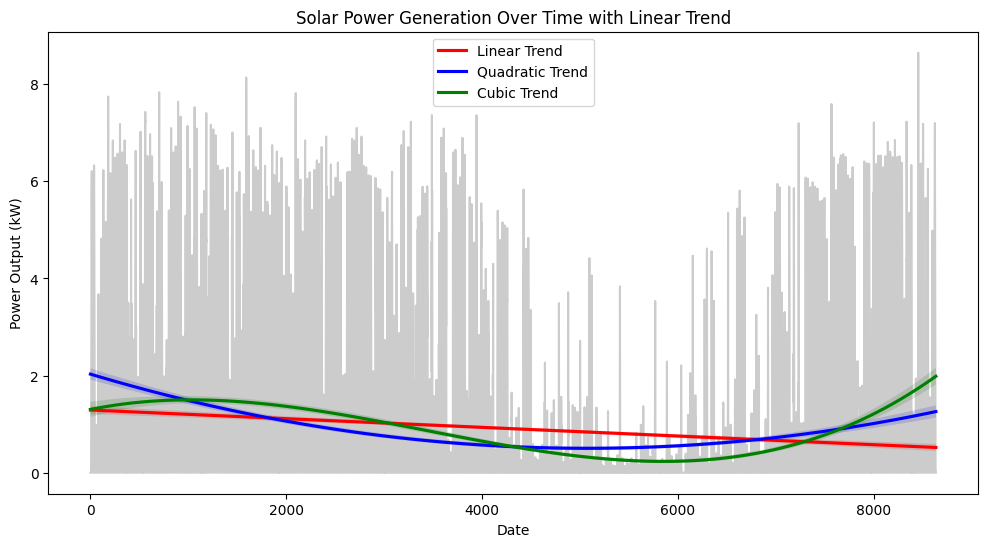

In [10]:
# plot from_pv_kw over time and a linear trend line
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x=data.reset_index().index, y="from_pv_kw", color="black", alpha=0.2)
sns.regplot(data=data, x=data.reset_index().index, y="from_pv_kw", scatter=False, color="red", label="Linear Trend")
sns.regplot(data=data, x=data.reset_index().index, y="from_pv_kw", order=2, scatter=False, color="blue", label="Quadratic Trend")
sns.regplot(data=data, x=data.reset_index().index, y="from_pv_kw", order=3, scatter=False, color="green", label="Cubic Trend")
plt.title("Solar Power Generation Over Time with Linear Trend")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.legend()
plt.show()

# Your Turn

Now it's your turn to play with the data. You can use other time series and try different window sizes for the SMA. You can also try different functional forms for the trend line, such as polynomial regression.

In [13]:
data["total_consumption_kw_rolling_mean_3"] = data["total_consumption_kw"].rolling(window=3).mean()
data["total_consumption_kw_rolling_mean_6"] = data["total_consumption_kw"].rolling(window=6).mean()
data["total_consumption_kw_rolling_mean_12"] = data["total_consumption_kw"].rolling(window=12).mean()

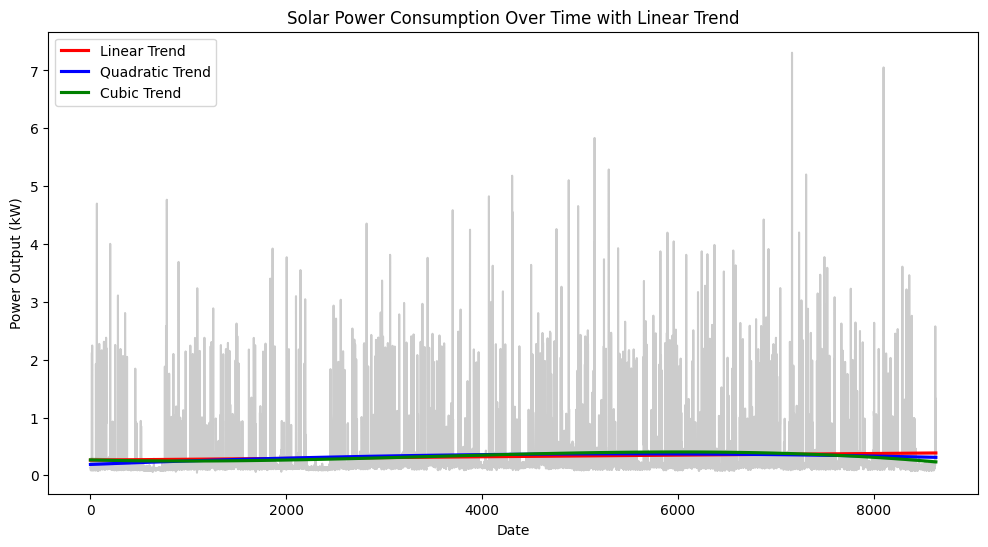

In [14]:
# plot from_pv_kw over time and a linear trend line
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x=data.reset_index().index, y="total_consumption_kw", color="black", alpha=0.2)
sns.regplot(data=data, x=data.reset_index().index, y="total_consumption_kw", scatter=False, color="red", label="Linear Trend")
sns.regplot(data=data, x=data.reset_index().index, y="total_consumption_kw", order=2, scatter=False, color="blue", label="Quadratic Trend")
sns.regplot(data=data, x=data.reset_index().index, y="total_consumption_kw", order=3, scatter=False, color="green", label="Cubic Trend")
plt.title("Solar Power Consumption Over Time with Linear Trend")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.legend()
plt.show()